In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3773/NGC-3773_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3773/NGC-3773_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [3]:
image_cut = image[70:170, 0:1890]
image_error_cut = image_error[70:170, 0:1890]

Text(0.5, 0, 'wavelength')

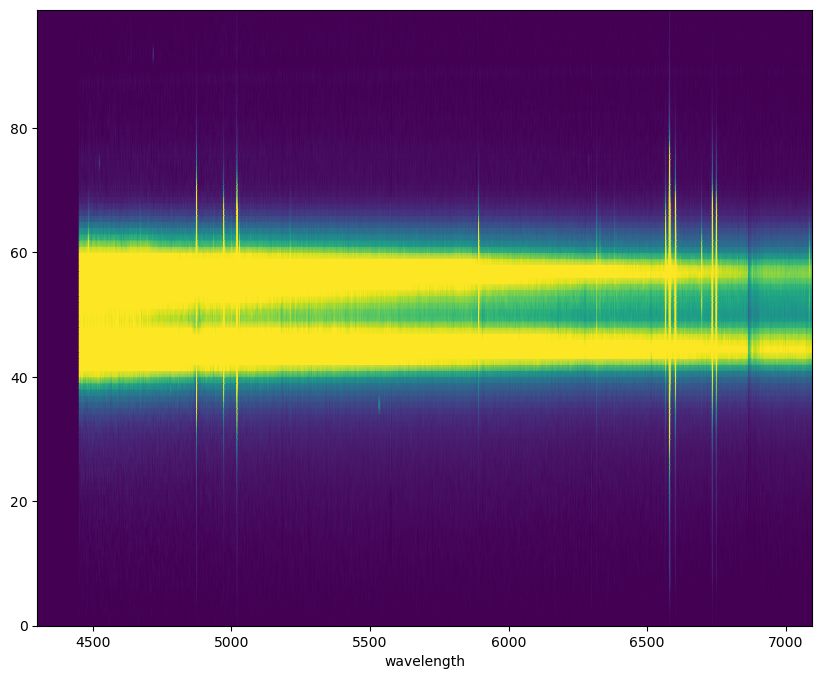

In [4]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

In [5]:
z = 0.00328
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3773/PSF/Real_seeing_NGC3773.txt")
sigmas = seeing / 2.35
print(sigmas)

[1.01016511 1.12309039 1.00840577 0.99664427 1.1197505  1.01319149]


Text(0.5, 1.0, 'H$\\alpha$')

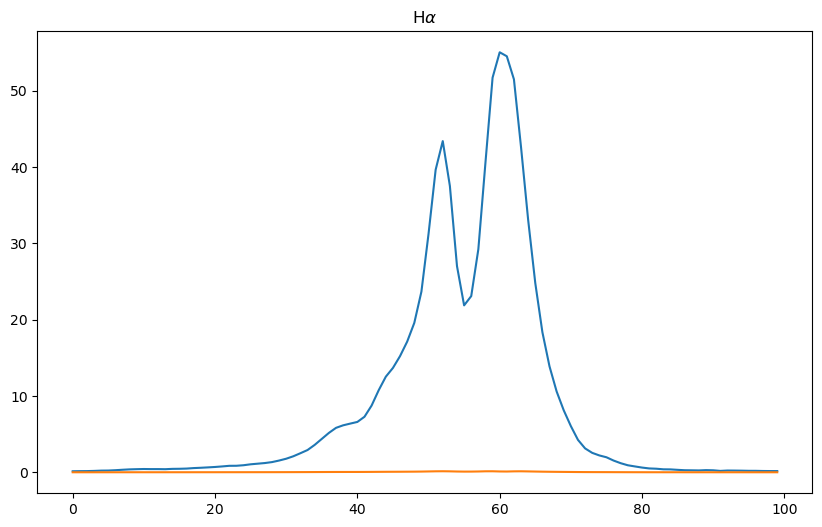

In [6]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3773/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [7]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) #+
        #sersic_1d(x_hr, *params[12:16]) #+
        #sersic_1d(x_hr, *params[16:20])+ 
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 100)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 100)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 20),
    (0, 50),
    (0.1, 10),
    (43, 45),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (48, 53),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (57, 62), 
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [8]:
# Bounds:
n_component = 3
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 9178.584421796335
differential_evolution step 2: f(x)= 5134.595807169071
differential_evolution step 3: f(x)= 5134.595807169071
differential_evolution step 4: f(x)= 2790.631497785669
differential_evolution step 5: f(x)= 1425.0970100072896
differential_evolution step 6: f(x)= 1425.0970100072896
differential_evolution step 7: f(x)= 1425.0970100072896
differential_evolution step 8: f(x)= 1425.0970100072896
differential_evolution step 9: f(x)= 1425.0970100072896
differential_evolution step 10: f(x)= 1354.1339409283376
differential_evolution step 11: f(x)= 1354.1339409283376
differential_evolution step 12: f(x)= 1354.1339409283376
differential_evolution step 13: f(x)= 794.0883958727941
differential_evolution step 14: f(x)= 794.0883958727941
differential_evolution step 15: f(x)= 382.33245907330786
differential_evolution step 16: f(x)= 382.33245907330786
differential_evolution step 17: f(x)= 382.33245907330786
differential_evolution step 18: f(x)= 382.3324

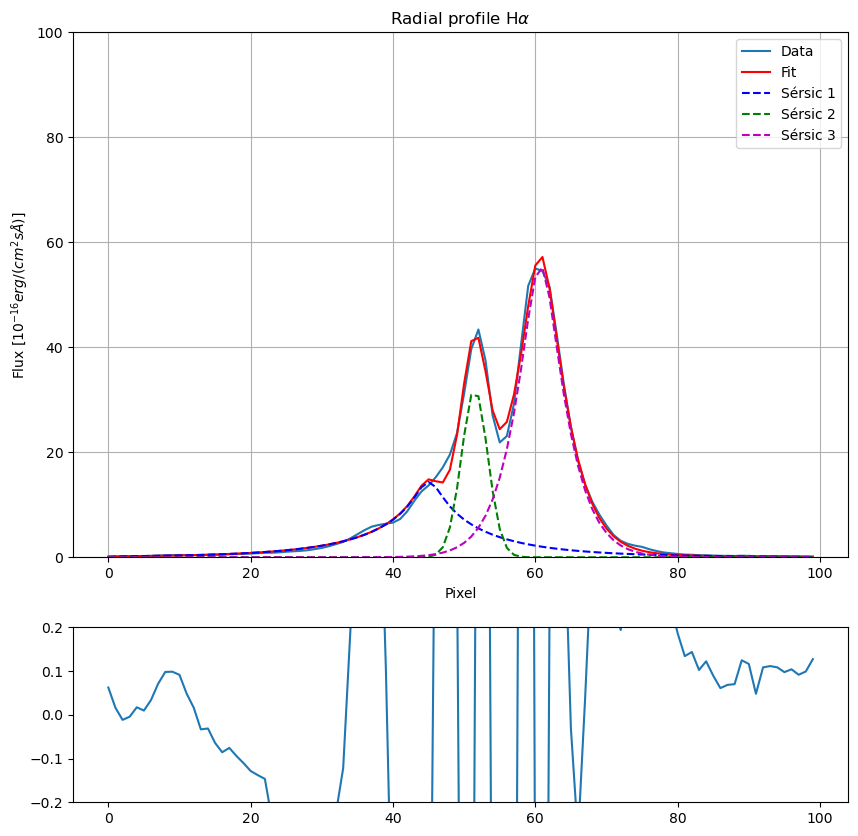

In [9]:
plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [10]:
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA)

print("Optimize parameters with curve fit:")

chi2_reduced_HA_1, dof_HA_1, chi2_HA_1 = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=1.6212, r_e=18.3895, n=1.4945, x_0=46.6091
Sérsic 2: I_e=25.9875, r_e=1.4570, n=0.2439, x_0=51.6237
Sérsic 3: I_e=14.4564, r_e=5.5721, n=0.9455, x_0=60.7396
[ 0.18128523  0.73425985  0.07105764  0.39656987 14.89902705  0.17908407
  0.53965834  0.14313506  0.75729219  0.13332863  0.05003426  0.13041291]
5.768956296967726


In [23]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) #+
        #sersic_1d(x_hr, *params[16:20])+ 
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 100)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 100)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 20),
    (0, 50),
    (0.1, 10),
    (43, 45),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (48, 53),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (57, 62), 

     (0, 20),
    (0, 50),
    (0.1, 10),
    (34, 37)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [24]:
# Bounds:
n_component = 4
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 9675.190743031084
differential_evolution step 2: f(x)= 9675.190743031084
differential_evolution step 3: f(x)= 9675.190743031084
differential_evolution step 4: f(x)= 9675.190743031084
differential_evolution step 5: f(x)= 9675.190743031084
differential_evolution step 6: f(x)= 9675.190743031084
differential_evolution step 7: f(x)= 9675.190743031084
differential_evolution step 8: f(x)= 9675.190743031084
differential_evolution step 9: f(x)= 7185.235855110246
differential_evolution step 10: f(x)= 5935.250472382612
differential_evolution step 11: f(x)= 5935.250472382612
differential_evolution step 12: f(x)= 5935.250472382612
differential_evolution step 13: f(x)= 3534.6134898591836
differential_evolution step 14: f(x)= 3518.5431285304217
differential_evolution step 15: f(x)= 3518.5431285304217
differential_evolution step 16: f(x)= 3518.5431285304217
differential_evolution step 17: f(x)= 3518.5431285304217
differential_evolution step 18: f(x)= 3518.543128530

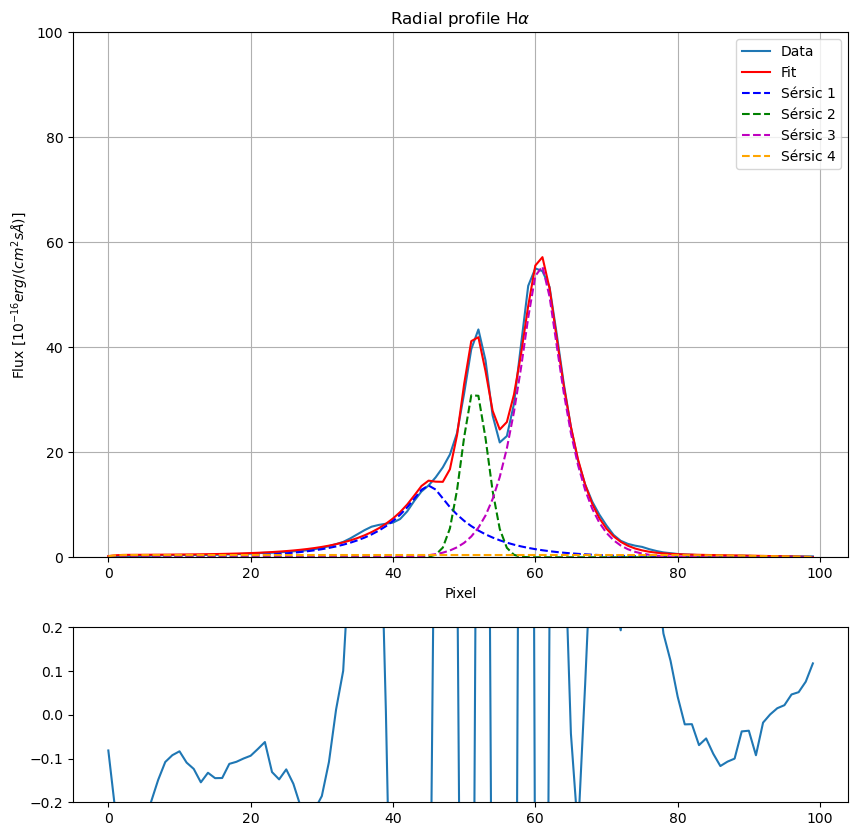

In [25]:
plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [26]:
bounds = [
    (0, 10),
    (0, 10),
    (0.1, 10),
    (44, 46),

    (0, 1),
    (20, 40),
    (0.1, 10),
    (50, 53),

    (0, 20),
    (0, 10),
    (0.1, 10),
    (59, 61), 

    (0, 10),
    (0, 5),
    (0.1, 10),
    (34, 37)
]
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA) #, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA_2, dof_HA_2, chi2_HA_2 = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16712\2569162179.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16712\2569162179.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=4.5037, r_e=9.8083, n=0.7544, x_0=47.9275
Sérsic 2: I_e=22.1998, r_e=1.3163, n=0.3046, x_0=51.6341
Sérsic 3: I_e=13.7658, r_e=5.5748, n=0.9577, x_0=60.8788
Sérsic 4: I_e=0.3581, r_e=35.2799, n=0.8495, x_0=45.7615
[ 1.24688903  1.19684409  0.12666374  2.49930044 18.43174374  0.42326535
  0.75767887  0.12548873  1.1434273   0.19706277  0.05100925  0.17976099
  0.11522124  5.52657564  1.21551613  1.02064759]
3.0421335135912364


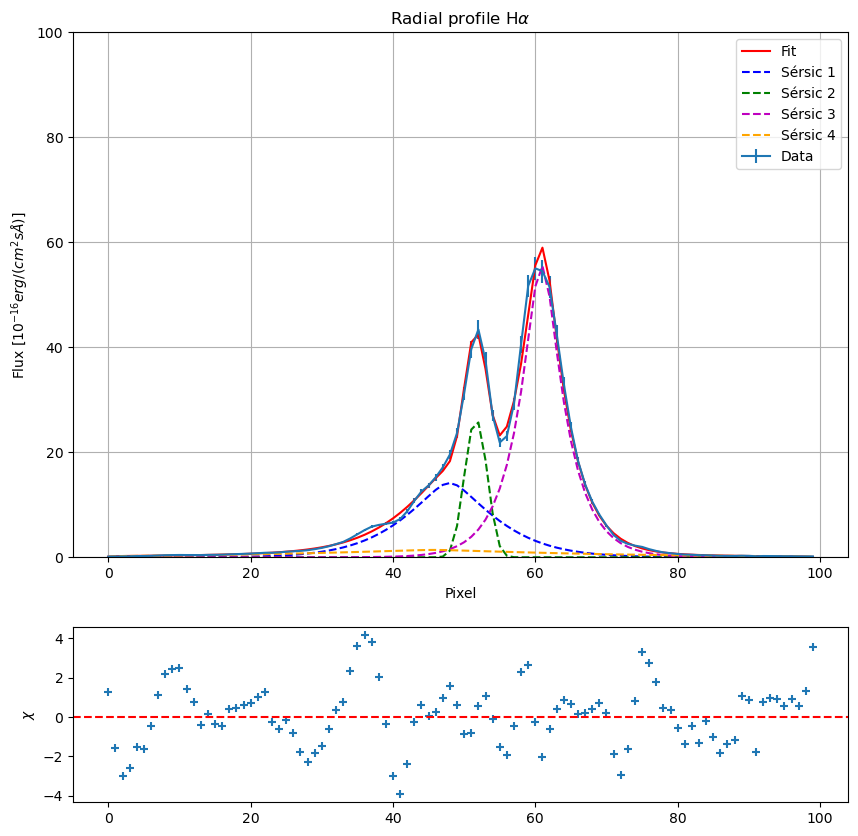

In [29]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [27]:
from scipy.stats import f
chi2_1 = chi2_HA_1
chi2_2 =  chi2_HA_2
dof_1 = dof_HA_1
dof_2 = dof_HA_1
# F-statistic
num = (chi2_1 - chi2_2) / (dof_1 - dof_2)
den = chi2_2 / dof_2
F = num / den
# p-value 
p_value = 1 - f.cdf(F, dof_1 - dof_2, dof_2)
print("F =", F)
print("p-value =", p_value)


F = inf
p-value = nan


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16712\2516229832.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  num = (chi2_1 - chi2_2) / (dof_1 - dof_2)


In [28]:
num

inf